**PONCTUALITÉ DES LIGNES TGV DE LA SNCF**

La SNCF analyse régulièrement la ponctualité de ses lignes TGV afin de proposer aux voyageurs l’expérience la plus qualitative possible. 

Ainsi, des retards peuvent perturber la satisfaction voyageur? Mais également les autres trains en circulation, causant alors des risques de suraccumulation du retard. 

Dès lors, identifier la ligne avec le plus de retard permettra à la société d’agir et de proposer des correctifs précis. 

Au cours de cette analyse, nous nous poserons les questions suivantes : 

* Au cours de l’année dernière, quel a été le classement  ligne TGV Nationales les plus en retard ? (% & min)

* Depuis 2018 quelle est le classement des lignes TGV Nationales les plus en retard ? (% & min)

* Depuis 2018, quelle est l’évolution du retard sur les lignes TGV Nationales (%)



**NOTRE HYPOTHESE INITIALE :**

**Notre hypothèse nulle (H0)** est que toutes les lignes TGV sont en retard de manière égale.

**Notre hypothèse alternative (H1)** est que certaines lignes TGV sont plus en retard que d’autres. 

Pour tester ces hypothèses, nous ferons usage d'une évaluation par ANOVA (sous condition de validation des critères nécessaires à cette évaluation) permettant d'exposer les différences entre les groupes. 


Setup de l'environnement de travail : 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from scipy import stats
import scikit_posthocs as sp
from fx import (
    sncf_ligne, 
    sncf_reel,
    sncf_percent,
    sncf_timing,
    plt_classement,
    sncf_classement,
    k_w,   
    )

In [ ]:
#connexion avec l'API SNCF pour récupérer les données : 

URL = "https://ressources.data.sncf.com/api/explore/v2.1/catalog/datasets/regularite-mensuelle-tgv-aqst/records"

all_record = [] #stockage des données paginées 
offset = 0 #pagination
limit = 100 #limite maximale de l'API

while True : #boucle 1 : récupération des données 1 à 10 000 (limite de l'API)
    current_limit = min(limit, 9000 - offset)
    params = {
        "offset" : offset,
        "limit" : current_limit,
        "order_by" : "date asc, gare_depart asc, gare_arrivee asc"
    }
    response = requests.get(URL, params=params)
    data = response.json() #stockage en json pour création du DataFrame

    results = data["results"]
    total_count = data["total_count"]

    if not results :
        break #mise en pause de la boucle si aucuns résultats

    all_record.extend(results) #stockage des données dans notre liste
    print(f"Données collectées {len(all_record)} / {total_count}")

    offset += limit #pagination adaptative pour récupérer l'ensemble de la data

    if offset == 9000 : 
        break #mise en pause lorsque l'ont arrive à la limite

stop = total_count - offset #setup de la limite maximale pour la seconde boucle
offset = 0 # reset de la limite de pagination

while True: #boucle 2 : récupération des données 10 001 à total_count (sens inverse)
    current_limit = min(limit, stop - offset)
    params = {
        "offset" : offset,
        "limit" : current_limit,
        "order_by" : "date desc, gare_depart desc, gare_arrivee desc"
    }
    response = requests.get(URL, params=params)
    data = response.json() #stockage en json pour création du DataFrame

    results = data["results"]
    total_count = data["total_count"]

    if not results :
        break #mise en pause de la boucle si aucuns résultats

    all_record.extend(results) #stockage des données dans notre liste
    print(f"Données collectées {len(all_record)} / {total_count}")

    offset += limit #pagination adaptative pour récupérer l'ensemble de la data

    if offset >= stop : 
        break

df = pd.DataFrame(all_record) #création du DataFrame contenant les data collectées
df = df.sort_values("date").reset_index(drop=True) 



Données collectée 100 / 12544
Données collectée 200 / 12544
Données collectée 300 / 12544
Données collectée 400 / 12544
Données collectée 500 / 12544
Données collectée 600 / 12544
Données collectée 700 / 12544
Données collectée 800 / 12544
Données collectée 900 / 12544
Données collectée 1000 / 12544
Données collectée 1100 / 12544
Données collectée 1200 / 12544
Données collectée 1300 / 12544
Données collectée 1400 / 12544
Données collectée 1500 / 12544
Données collectée 1600 / 12544
Données collectée 1700 / 12544
Données collectée 1800 / 12544
Données collectée 1900 / 12544
Données collectée 2000 / 12544
Données collectée 2100 / 12544
Données collectée 2200 / 12544
Données collectée 2300 / 12544
Données collectée 2400 / 12544
Données collectée 2500 / 12544
Données collectée 2600 / 12544
Données collectée 2700 / 12544
Données collectée 2800 / 12544
Données collectée 2900 / 12544
Données collectée 3000 / 12544
Données collectée 3100 / 12544
Données collectée 3200 / 12544
Données collectée

In [3]:
df.duplicated().sum() #vérification de la présence de doublons liées à la collecte

np.int64(0)

In [4]:
df.head() #vérification de l'affichage du DataFrame

,date,service,gare_depart,gare_arrivee,duree_moyenne,nb_train_prevu,nb_annulation,commentaire_annulation,nb_train_depart_retard,retard_moyen_depart,...,nb_train_retard_sup_15,retard_moyen_trains_retard_sup15,nb_train_retard_sup_30,nb_train_retard_sup_60,prct_cause_externe,prct_cause_infra,prct_cause_gestion_trafic,prct_cause_materiel_roulant,prct_cause_gestion_gare,prct_cause_prise_en_charge_voyageurs
0,2018-01,National,AIX EN PROVENCE TGV,PARIS LYON,188,402,0,None,117,6.625641,...,37,4.417206,19,7,42.857143,22.857143,8.571429,22.857143,0.000000,2.857143
1,2018-01,National,PARIS MONTPARNASSE,QUIMPER,220,248,1,None,37,9.501351,...,26,7.548387,17,7,26.923077,38.461538,15.384615,19.230769,0.000000,0.000000
2,2018-01,National,PARIS MONTPARNASSE,POITIERS,93,506,4,None,62,7.717742,...,16,2.716932,6,0,26.923077,42.307692,11.538462,19.230769,0.000000,0.000000
3,2018-01,National,PARIS MONTPARNASSE,NANTES,124,508,3,None,71,7.235211,...,39,5.292211,18,8,33.333333,22.222222,16.666667,20.370370,5.555556,1.851852
4,2018-01,National,PARIS MONTPARNASSE,LE MANS,54,441,2,None,62,10.474462,...,22,2.997570,9,3,28.947368,26.315789,10.526316,26.315789,5.263158,2.631579


**PHASE 1 - Nettoyage de la donnée**

In [5]:
df.isnull().sum()

date                                        0
service                                     0
gare_depart                                 0
gare_arrivee                                0
duree_moyenne                               0
nb_train_prevu                              0
nb_annulation                               0
commentaire_annulation                  12544
nb_train_depart_retard                      0
retard_moyen_depart                         0
retard_moyen_tous_trains_depart             0
commentaire_retards_depart              12544
nb_train_retard_arrivee                     0
retard_moyen_arrivee                        0
retard_moyen_tous_trains_arrivee            0
commentaires_retard_arrivee             11846
nb_train_retard_sup_15                      0
retard_moyen_trains_retard_sup15            0
nb_train_retard_sup_30                      0
nb_train_retard_sup_60                      0
prct_cause_externe                          0
prct_cause_infra                  

Nous observons que le dataframe ne possède peu de valeurs nulles, seules les colonnes suivantes en contiennent : 

* *"commentaire_annulation"*
* *"commentaire_retards_depart"*
* *"commentaires_retard_arrivee"*

La SNCF caractérisant l'entrée de ces données comme facultative, leur absence est alors logique.

In [6]:
df.info() #verification du type pour chaque variable

<class 'pandas.DataFrame'>
RangeIndex: 12544 entries, 0 to 12543
Data columns (total 26 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  12544 non-null  str    
 1   service                               12544 non-null  str    
 2   gare_depart                           12544 non-null  str    
 3   gare_arrivee                          12544 non-null  str    
 4   duree_moyenne                         12544 non-null  int64  
 5   nb_train_prevu                        12544 non-null  int64  
 6   nb_annulation                         12544 non-null  int64  
 7   commentaire_annulation                0 non-null      object 
 8   nb_train_depart_retard                12544 non-null  int64  
 9   retard_moyen_depart                   12544 non-null  float64
 10  retard_moyen_tous_trains_depart       12544 non-null  float64
 11  commentaire_retards_depart

On observe que les dates ne sont pas au format *int*, et les mois ne sont pas séparés des années, ce que nous allons devoir corriger.

In [7]:
#passage des dates au bon format : 
df['date_dt'] = pd.to_datetime(df['date']) #passage au format date pandas
df['année'] = df['date_dt'].dt.year #setup de l'année en int
df['mois'] = df['date_dt'].dt.month #setup du mois en int
df = df.drop("date_dt", axis=1) #suppression de la colonne inutile suite à nos modifications

In [8]:
df.info() #verification du type après analyse

<class 'pandas.DataFrame'>
RangeIndex: 12544 entries, 0 to 12543
Data columns (total 28 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  12544 non-null  str    
 1   service                               12544 non-null  str    
 2   gare_depart                           12544 non-null  str    
 3   gare_arrivee                          12544 non-null  str    
 4   duree_moyenne                         12544 non-null  int64  
 5   nb_train_prevu                        12544 non-null  int64  
 6   nb_annulation                         12544 non-null  int64  
 7   commentaire_annulation                0 non-null      object 
 8   nb_train_depart_retard                12544 non-null  int64  
 9   retard_moyen_depart                   12544 non-null  float64
 10  retard_moyen_tous_trains_depart       12544 non-null  float64
 11  commentaire_retards_depart

A présent, nous voyons que la ligne TGV est écrite en deux colonnes, gare de départ | gare de d'arrivée. ?Nous allons devoir les fusionner afin d'obtenir une ligne unique pour faciliter notre analyse.

**EXEMPLE :** *La gare de départ AIX EN PROVENCE TGV et la gare d'arrivée PARIS LYON deviendront la ligne AIX EN PROVENCE TGV - PARIS LYON*

In [9]:
df['ligne_TGV'] = df.apply(sncf_ligne, axis=1) #creation de la serie ligne_TGV

In [ ]:
df.info() #verification de l'application de la fonction

<class 'pandas.DataFrame'>
RangeIndex: 12544 entries, 0 to 12543
Data columns (total 29 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  12544 non-null  str    
 1   service                               12544 non-null  str    
 2   gare_depart                           12544 non-null  str    
 3   gare_arrivee                          12544 non-null  str    
 4   duree_moyenne                         12544 non-null  int64  
 5   nb_train_prevu                        12544 non-null  int64  
 6   nb_annulation                         12544 non-null  int64  
 7   commentaire_annulation                0 non-null      object 
 8   nb_train_depart_retard                12544 non-null  int64  
 9   retard_moyen_depart                   12544 non-null  float64
 10  retard_moyen_tous_trains_depart       12544 non-null  float64
 11  commentaire_retards_depart

Nous avons pu également constater que le service se divise en deux variables : 
* *National*
* *International*

Or notre analyse se focalise uniquement sur les lignes nationales de la SNCF, ainsi, nous allons retirer toutes les lignes n'appartenant pas à cette condition.

In [11]:
df = df.loc[df['service'] == "National"]
df['service'].unique() #verification de la bonne application de la formule.

<StringArray>
['National']
Length: 1, dtype: str

A présent, nous allons pouvoir calculer nos indicateurs de retard :

In [12]:
df['train_total'] = df.apply(sncf_reel, axis=1) #création du total de train partit
df['train_retard'] = df["nb_train_retard_arrivee"] #création de la colonne des retards effectifs
df['pourcentage_retard'] = df.apply(sncf_percent, axis=1) #création du pourcentage de retard mensuel sur la ligne
df['min_retard'] = abs(df["retard_moyen_arrivee"]) #creation de l'indicateur moyen de retard total de la ligne, retirant les problème d'encodage (négatifs)
df['pourcentage_retard_min'] = df.apply(sncf_timing, axis=1) #création de l'indicateur d'augmentation temporelle du trajet en pourcent

**NOTE DE COMPRÉHENSION :**

Le nombre de trains en retard à l'arrivée a été choisi comme indicateur du retard sur la ligne, car il s'agit du type de retard le plus impactant pour les voyageurs.

De plus, un train en retard au départ de la ligne ne signifie pas forcément un retard à l'arrivée car il peut le "rattraper". 

Donc, que ce soit pour les minutes ou la qualification d'un retard, nous utiliserons l'arrivée comme facteur discriminant.

A présent, nous allons supprimer les colonnes n'étant pas utiles à notre analyse afin de faciliter la lecture et les calculs sur les données.

In [13]:
USEFUL_COLS = ["date", 
               "gare_depart", 
               "gare_arrivee",
               "train_total",
               "train_retard",
               "pourcentage_retard",
               "année", 
               "mois",
               "ligne_TGV",
               "min_retard", 
               "pourcentage_retard_min",
               ] #liste de l'ensemble des colonnes utiles à notre analyse

for cols in df.columns : #boucle de suppression des colonnes hors liste
    if cols not in USEFUL_COLS : 
        df = df.drop(cols, axis = 1)

df.head() #vérification de l'application de la boucle

,date,gare_depart,gare_arrivee,année,mois,ligne_TGV,train_total,train_retard,pourcentage_retard,min_retard,pourcentage_retard_min
0,2018-01,AIX EN PROVENCE TGV,PARIS LYON,2018,1,AIX EN PROVENCE TGV - PARIS LYON,402,37,9.203980,35.974324,19.135279
1,2018-01,PARIS MONTPARNASSE,QUIMPER,2018,1,PARIS MONTPARNASSE - QUIMPER,247,26,10.526316,55.692308,25.314685
2,2018-01,PARIS MONTPARNASSE,POITIERS,2018,1,PARIS MONTPARNASSE - POITIERS,502,52,10.358566,13.484936,14.499931
3,2018-01,PARIS MONTPARNASSE,NANTES,2018,1,PARIS MONTPARNASSE - NANTES,505,58,11.485149,33.726437,27.198739
4,2018-01,PARIS MONTPARNASSE,LE MANS,2018,1,PARIS MONTPARNASSE - LE MANS,439,65,14.806378,16.904615,31.304843


A présent, nous allons réorganiser l'ensemble de notre dataframe afin de faciliter la lecture.

In [14]:
ordre = ["date", 
         "mois", 
         "année", 
         "gare_depart", 
         "gare_arrivee", 
         "ligne_TGV", 
         "train_total", 
         "train_retard", 
         "pourcentage_retard",
         "min_retard",
         "pourcentage_retard_min",
         ] #définition manuelle de l'ordre du DataFrame

df = df[ordre] #application de l'ordre

df.head() #verification de la bonne application. 

,date,mois,année,gare_depart,gare_arrivee,ligne_TGV,train_total,train_retard,pourcentage_retard,min_retard,pourcentage_retard_min
0,2018-01,1,2018,AIX EN PROVENCE TGV,PARIS LYON,AIX EN PROVENCE TGV - PARIS LYON,402,37,9.203980,35.974324,19.135279
1,2018-01,1,2018,PARIS MONTPARNASSE,QUIMPER,PARIS MONTPARNASSE - QUIMPER,247,26,10.526316,55.692308,25.314685
2,2018-01,1,2018,PARIS MONTPARNASSE,POITIERS,PARIS MONTPARNASSE - POITIERS,502,52,10.358566,13.484936,14.499931
3,2018-01,1,2018,PARIS MONTPARNASSE,NANTES,PARIS MONTPARNASSE - NANTES,505,58,11.485149,33.726437,27.198739
4,2018-01,1,2018,PARIS MONTPARNASSE,LE MANS,PARIS MONTPARNASSE - LE MANS,439,65,14.806378,16.904615,31.304843


Pour la dernière étape de notre nettoyage de donnée, nous allons vérifier la cohérence interne de nos valeurs.

In [15]:
df.describe() #vérification de la cohérence interne

,mois,année,train_total,train_retard,pourcentage_retard,min_retard,pourcentage_retard_min
count,11012.000000,11012.000000,11012.000000,11012.000000,11012.000000,11012.000000,11012.000000
mean,6.324283,2021.742554,284.974936,41.065656,14.503251,35.038473,25.148635
std,3.448322,2.478225,182.136575,32.491178,7.753431,15.073393,11.488084
min,1.000000,2018.000000,-21.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,2020.000000,168.000000,18.000000,9.316770,25.432639,17.554157
50%,6.000000,2022.000000,242.000000,33.000000,13.170187,33.089951,23.024233
75%,9.000000,2024.000000,385.000000,56.000000,18.249651,42.292969,30.406928
max,12.000000,2026.000000,1099.000000,376.000000,100.000000,299.600000,135.579710


Nous pouvons observer que la colonne train total possède un nombre minimal négatif, traduisant une incohérence dans les valeurs, dont il faut identifier la cause : 

In [16]:
# Analyse des variables incohérentes dans train total : 

df.loc[df["train_total"] < 0]

,date,mois,année,gare_depart,gare_arrivee,ligne_TGV,train_total,train_retard,pourcentage_retard,min_retard,pourcentage_retard_min
3405,2020-04,4,2020,PARIS LYON,SAINT ETIENNE CHATEAUCREUX,PARIS LYON - SAINT ETIENNE CHATEAUCREUX,-4,0,-0.0,0.0,0.0
3406,2020-04,4,2020,PARIS LYON,TOULON,PARIS LYON - TOULON,-13,0,-0.0,0.0,0.0
3413,2020-04,4,2020,PARIS MONTPARNASSE,LA ROCHELLE VILLE,PARIS MONTPARNASSE - LA ROCHELLE VILLE,-15,0,-0.0,0.0,0.0
3415,2020-04,4,2020,PARIS LYON,PERPIGNAN,PARIS LYON - PERPIGNAN,-11,0,-0.0,0.0,0.0
3426,2020-04,4,2020,PARIS LYON,GRENOBLE,PARIS LYON - GRENOBLE,-10,0,-0.0,0.0,0.0
3429,2020-04,4,2020,PARIS LYON,CHAMBERY CHALLES LES EAUX,PARIS LYON - CHAMBERY CHALLES LES EAUX,-15,0,-0.0,0.0,0.0
3432,2020-04,4,2020,PARIS LYON,NICE VILLE,PARIS LYON - NICE VILLE,-9,0,-0.0,0.0,0.0
3434,2020-04,4,2020,PARIS LYON,BELLEGARDE (AIN),PARIS LYON - BELLEGARDE (AIN),-15,0,-0.0,0.0,0.0
3439,2020-04,4,2020,TOURS,PARIS MONTPARNASSE,TOURS - PARIS MONTPARNASSE,-11,0,-0.0,0.0,0.0
3440,2020-04,4,2020,TOURCOING,BORDEAUX ST JEAN,TOURCOING - BORDEAUX ST JEAN,-2,0,-0.0,0.0,0.0


Nous constatons que les années négatives sont le résultat du COVID-19. 

Ainsi, lors de cette période, la SNCF a reporté les trains planifiés en tant que train annulé, d'où l'erreur dans notre calcul du total.

De ce fait, nous allons supprimer ces données car elles ne sont pas analysables, et que les remplacer par 0 ne transformerait pas notre analyse.

In [17]:
df = df.loc[df["train_total"] >= 0] #suppression des valeurs issues du COVID19
df.describe() #vérification

,mois,année,train_total,train_retard,pourcentage_retard,min_retard,pourcentage_retard_min
count,10966.000000,10966.000000,10966.000000,10966.000000,10966.000000,10966.000000,10966.000000
mean,6.333394,2021.749863,286.207459,41.237917,14.564089,35.185452,25.254128
std,3.452592,2.480841,181.518806,32.449977,7.712442,14.932795,11.395849
min,1.000000,2018.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,2020.000000,170.000000,18.000000,9.363609,25.568362,17.618507
50%,6.000000,2022.000000,243.000000,33.000000,13.204135,33.148333,23.087184
75%,9.000000,2024.000000,386.000000,56.000000,18.278868,42.331214,30.466375
max,12.000000,2026.000000,1099.000000,376.000000,100.000000,299.600000,135.579710


Une dernière variable semble incohérente : *pourcentage retard min* qui représente l'augmentation en % de la durée du trajet. 
Sachant qu'il ne s'agit pas d'une donnée figée et qu'un retard peut excéder la durée totale du trajet, il n'est pas incohérent de retrouver des valeurs au-delà de 100%.

Nous avons conclu cette phase de nettoyage du dataframe, et nous possédons désormais un jeu de données propre et exploitable pour l'analyse.

**PHASE 2 - Exploratory Data Analysis (EDA)**

À présent, nous allons débuter la phase 2 de notre analyse, l'exploration des données. 

L'objectif est de comprendre notre jeu de données.

Nous débuterons par la visualisation de la distribution des variables.

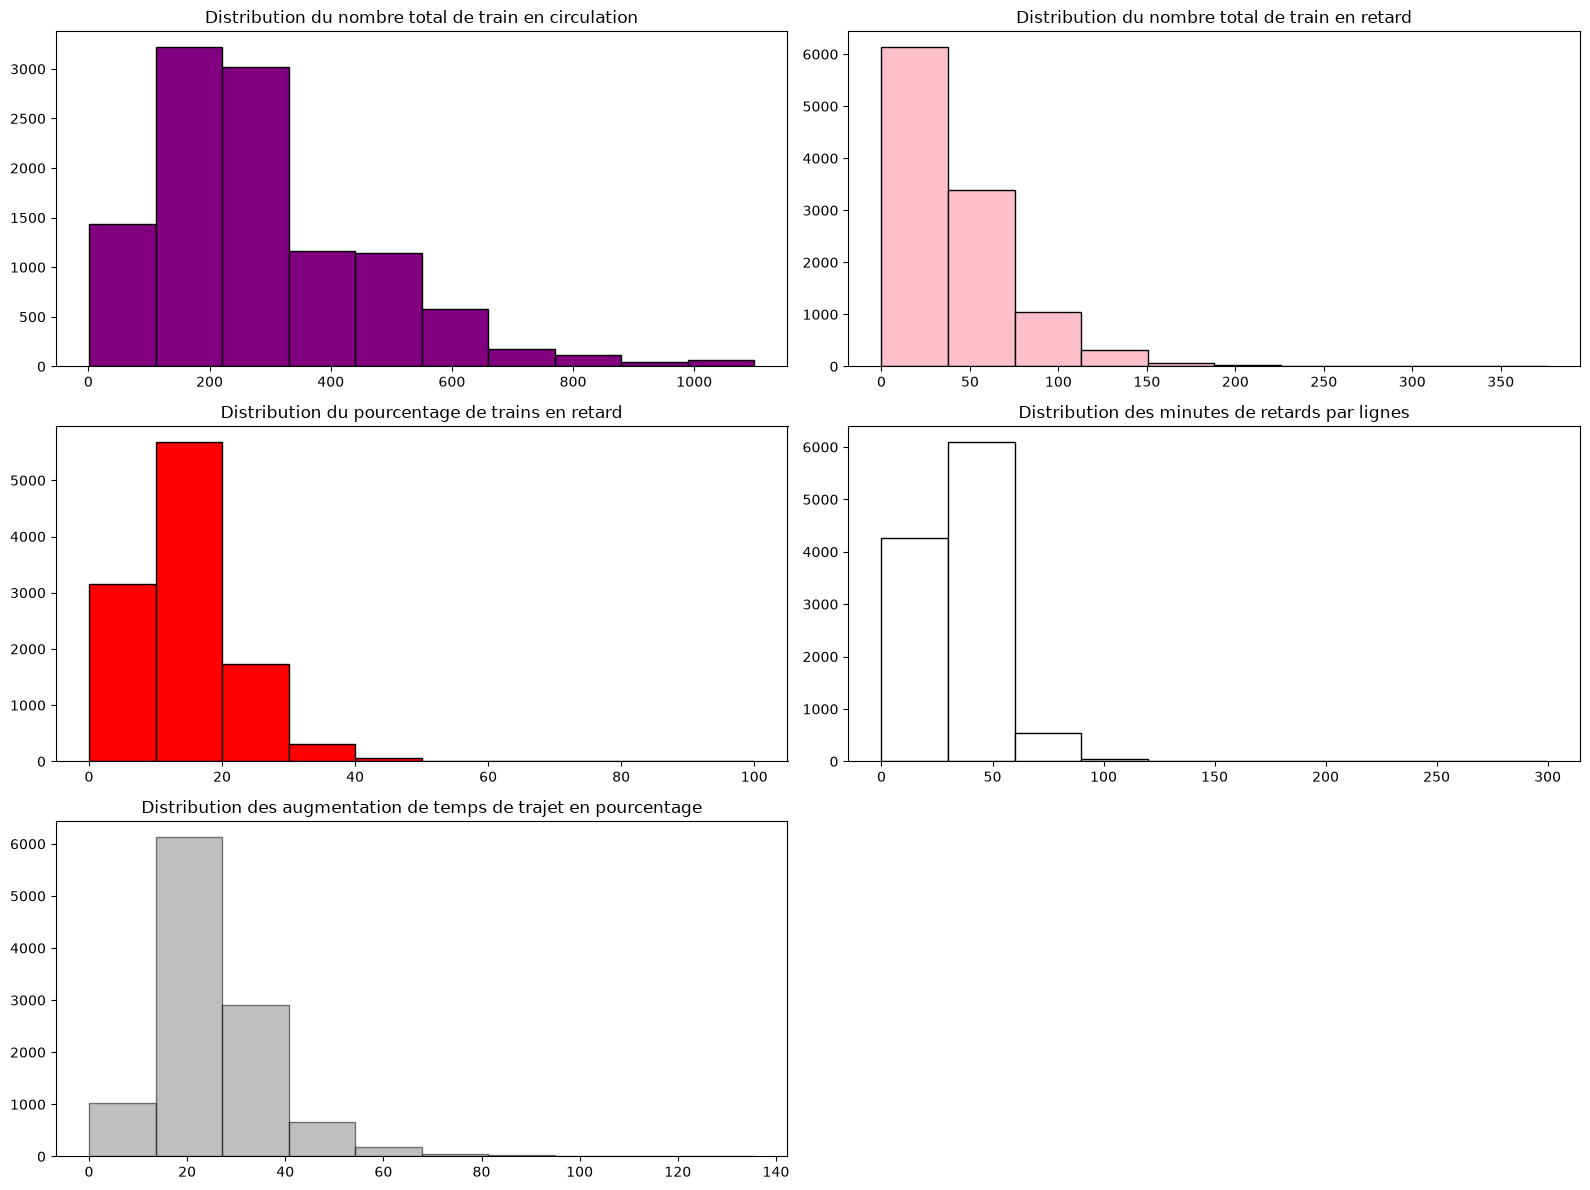

In [18]:
#visualisation de la distribution des variables quantitatives : 

plt.figure(figsize=(16,12))
plt.subplot(3,2,1)
plt.hist(df['train_total'], color="purple", alpha=1, edgecolor="black")
plt.title("Distribution du nombre total de train en circulation")
plt.subplot(3,2,2)
plt.hist(df['train_retard'], color="pink", alpha=1, edgecolor="black")
plt.title("Distribution du nombre total de train en retard")
plt.subplot(3,2,3)
plt.hist(df['pourcentage_retard'], color="red", alpha=1, edgecolor="black")
plt.title("Distribution du pourcentage de trains en retard")
plt.subplot(3,2,4)
plt.hist(df['min_retard'], color="white", edgecolor="black")
plt.title("Distribution des minutes de retards par lignes")
plt.subplot(3,2,5)
plt.hist(df['pourcentage_retard_min'], color="grey", alpha= 0.5,edgecolor="black")
plt.title("Distribution des augmentation de temps de trajet en pourcentage")
plt.tight_layout()

In [19]:
#vérification mathématique de la distribution de nos variables : 

testing_cols = ['train_total', 'train_retard', 'pourcentage_retard', 'min_retard', 'pourcentage_retard_min']

for cols in testing_cols : 
    skewness = df[cols].skew()
    kurto = df[cols].kurtosis()
    print(f"La distribution de {cols} possède un skewness de {skewness.round(2)} et un kurtosis de {kurto.round(2)}")



La distribution de train_total possède un skewness de 1.19 et un kurtosis de 1.85
La distribution de train_retard possède un skewness de 1.66 et un kurtosis de 4.78
La distribution de pourcentage_retard possède un skewness de 2.05 et un kurtosis de 12.19
La distribution de min_retard possède un skewness de 2.16 et un kurtosis de 19.5
La distribution de pourcentage_retard_min possède un skewness de 1.66 et un kurtosis de 5.87


Cette évaluation démontre une distribution de nos variables éloignée de la loi normale, ce qui influencera le choix futur de nos tests statistiques.

À présent, nous allons étudier graphiquement les relations entre nos différentes variables :

In [20]:
df.describe()

,mois,année,train_total,train_retard,pourcentage_retard,min_retard,pourcentage_retard_min
count,10966.000000,10966.000000,10966.000000,10966.000000,10966.000000,10966.000000,10966.000000
mean,6.333394,2021.749863,286.207459,41.237917,14.564089,35.185452,25.254128
std,3.452592,2.480841,181.518806,32.449977,7.712442,14.932795,11.395849
min,1.000000,2018.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,2020.000000,170.000000,18.000000,9.363609,25.568362,17.618507
50%,6.000000,2022.000000,243.000000,33.000000,13.204135,33.148333,23.087184
75%,9.000000,2024.000000,386.000000,56.000000,18.278868,42.331214,30.466375
max,12.000000,2026.000000,1099.000000,376.000000,100.000000,299.600000,135.579710


<Axes: >

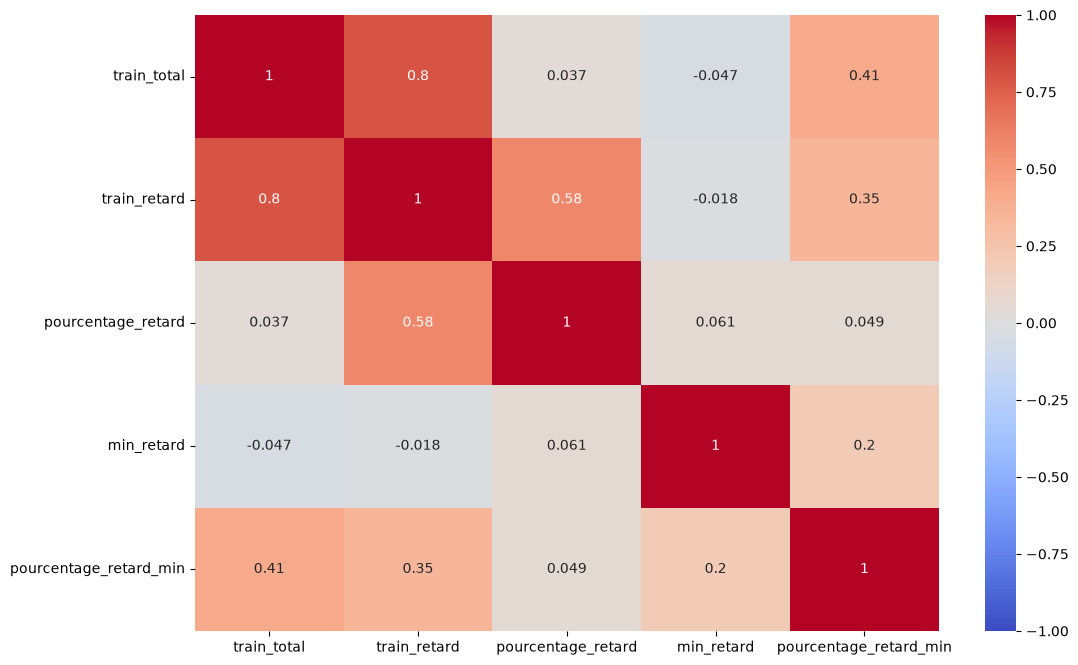

In [21]:
#Visualisation par HeatMap de la relation entre les variables : 

matrice_corr = df.drop(["année", "mois"], axis=1) #suppression des variables numériques inutiles à l'analyse

matrice = matrice_corr.corr(method='spearman', numeric_only=True) #utilisation du Rho de spearman car présence de variables discrète (nombre de train en circulation)
plt.figure(figsize=(12,8))
sns.heatmap(matrice, annot=True, cmap='coolwarm', vmin=-1, vmax=1, annot_kws={"size": 10})

Cette heatmap illustre la présence de corrélations entre certaines variables de notre jeu de données. Ainsi, les variables suivantes possèdent un lien hypothétique : 

* train total - train en retard
* train total - pourcentage d'augmentation du trajet
* train retard - pourcentage de train en retard
* train retard - pourcentage d'augmentation du trajet

Ces différents liens peuvent s’expliquer en s’intéressant à la logique de programmation des trains. Ainsi, si plus de trains circulent, le risque de retard augmente également, expliquant alors la corrélation importante entre ces deux variables. Cette logique se retrouve également dans le lien entre le nombre de trains en circulation et le pourcentage d’augmentation du temps du trajet. 

Autrement, les deux autres corrélations peuvent s’expliquer par le fait que les variables sont toutes deux utilisées dans le calcul de l’autre expliquant les liens. 


Nous allons à présent conclure cette phase initiale d'analyse de nos données par l'identification des outils, qui nous permettront d'adopter les bonnes statistiques par la suite.

Text(0, 0.5, 'Z-Score')

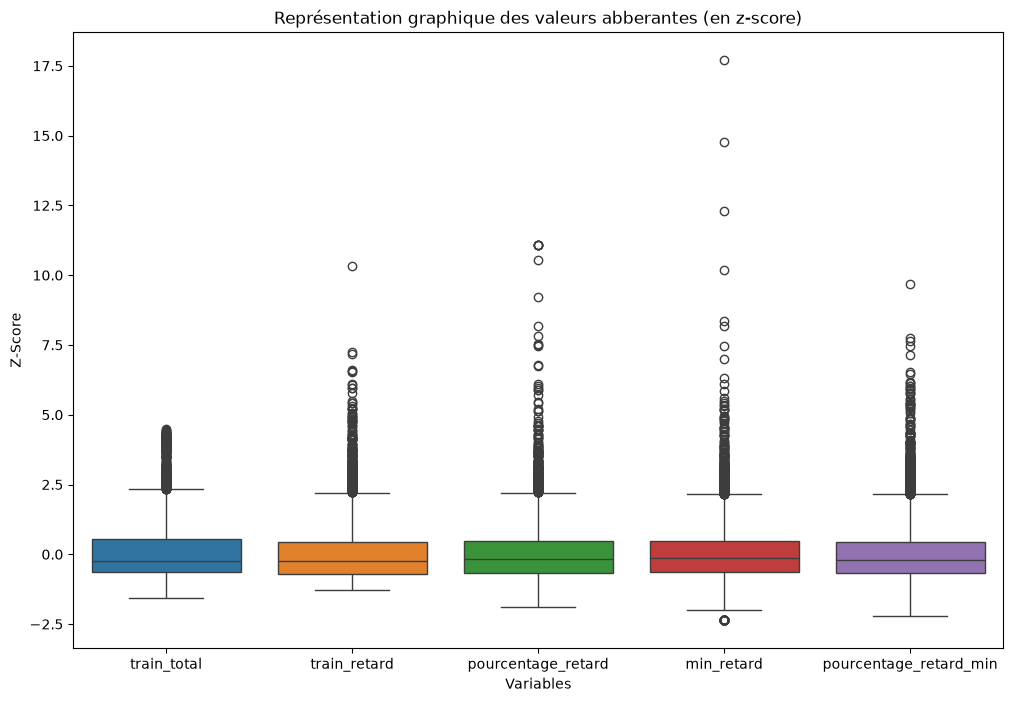

In [23]:
#Identification des outliers par visualisation graphique : 

box = df.drop(["année", "mois", "date", "gare_depart", "gare_arrivee", "ligne_TGV"], axis=1)
z_box = (box - box.mean(axis=0)) / box.std(axis=0) #normalisation des données par zscore

plt.figure(figsize=(12,8)) #visualisation graphique par boxplot
sns.boxplot(z_box)
plt.title("Représentation graphique des valeurs abberantes (en z-score)")
plt.xlabel("Variables")
plt.ylabel("Z-Score")

Ce graphique démontre la présence de nombreux outils dans notre jeu de données. Ainsi, les tests statistiques réalisés dans la suite de l'analyse devront prendre en compte la présence de ces variables afin de ne pas être faussées.

Cette analyse renforce la vision de la distribution que nous avons pu illustrer plus haut. De plus, certaines valeurs sont dépendantes, expliquant alors la répartition aussi importante de valeurs aberrantes dans notre analyse.

À présent, nous allons conclure cette phase d'analyse exploratoire par la visualisation des effectifs de chacune de nos lignes TGV

In [24]:
#analyse des classe : 

df['ligne_TGV'].unique().value_counts() #dénombrage du nombre de lignes TGV

AIX EN PROVENCE TGV - PARIS LYON         1
PARIS MONTPARNASSE - QUIMPER             1
PARIS MONTPARNASSE - POITIERS            1
PARIS MONTPARNASSE - NANTES              1
PARIS MONTPARNASSE - LE MANS             1
                                        ..
MARSEILLE ST CHARLES - TOURCOING         1
METZ - PARIS EST                         1
MARSEILLE ST CHARLES - LYON PART DIEU    1
BARCELONA - PARIS LYON                   1
PARIS LYON - BARCELONA                   1
Name: count, Length: 116, dtype: int64

In [25]:
#Analyse pour les % par lignes : 

v_count = df.groupby('ligne_TGV').pourcentage_retard.count() #count de la taille d'effectif

for ligne, effectif in v_count[v_count < 100].items() : #boucle pour identifier les effectifs inférieur à 100
    print(f"La ligne {ligne} ne possède que {effectif}")

La ligne BARCELONA - PARIS LYON ne possède que 9
La ligne BORDEAUX ST JEAN - PARIS VAUGIRARD ne possède que 12
La ligne BORDEAUX ST JEAN - TOURCOING ne possède que 98
La ligne MARSEILLE ST CHARLES - TOURCOING ne possède que 99
La ligne NANTES - PARIS VAUGIRARD ne possède que 12
La ligne PARIS LYON - BARCELONA ne possède que 9
La ligne PARIS VAUGIRARD - BORDEAUX ST JEAN ne possède que 12
La ligne PARIS VAUGIRARD - NANTES ne possède que 12
La ligne PARIS VAUGIRARD - RENNES ne possède que 12
La ligne RENNES - PARIS VAUGIRARD ne possède que 12
La ligne TOURCOING - BORDEAUX ST JEAN ne possède que 98
La ligne TOURCOING - MARSEILLE ST CHARLES ne possède que 13


Nous pouvons nous apercevoir d'un problème dans notre dataframe avec la présence de BARCELONA - PARIS LYON non encodée comme ligne internationale, nous allons la supprimer

In [61]:
df = df.loc[df['ligne_TGV'] != "BARCELONA - PARIS LYON"] #Suppression ligne mal encodée
df = df.loc[df['ligne_TGV'] != "PARIS LYON - BARCELONA"] #Suppression ligne mal encodée

In [62]:
for ligne, effectif in v_count[v_count < 90].items() : #Nouvelle boucle pour affiner et obtenir les groupes inférieurs à 90
    print(f"La ligne {ligne} ne possède que {effectif}")

Cette analyse nous démontre que 7 lignes possèdent une taille d'effectif inférieure à 90, de ce fait, afin de ne pas perturber notre analyse par leurs faibles occurrences, nous allons les supprimer.

In [28]:
kill_ligne = ["BORDEAUX ST JEAN - PARIS VAUGIRARD",
              "NANTES - PARIS VAUGIRARD",
              "PARIS VAUGIRARD - BORDEAUX ST JEAN",
              "PARIS VAUGIRARD - NANTES",
              "PARIS VAUGIRARD - RENNES",
              "RENNES - PARIS VAUGIRARD", 
              "TOURCOING - MARSEILLE ST CHARLES"]

for cols in kill_ligne : #boucle de suppression par loc des faibles effectifs 
    df = df.loc[df['ligne_TGV'] != cols]


In [29]:
#Analyse pour les minutes par lignes : 

v_count = df.groupby('ligne_TGV').min_retard.count() #count de la taille d'effectif

for ligne, effectif in v_count[v_count < 90].items() : #boucle pour identifier les effectifs inférieur à 100
    print(f"La ligne {ligne} ne possède que {effectif}")

À présent, plus aucune ligne ne possède un effectif inférieur à 90, ce qui nous permettra d'homogénéiser l'analyse globale.

**PHASE 3 : Analyse statistique complète**

Dans cette phase, nous allons réaliser les tests statistiques nécessaires pour apporter une réponse à nos questions initiales. 

In [30]:
#Statistiques descriptive de nos données

df.describe()

,mois,année,train_total,train_retard,pourcentage_retard,min_retard,pourcentage_retard_min
count,10863.000000,10863.000000,10863.000000,10863.000000,10863.000000,10863.000000,10863.000000
mean,6.332505,2021.772346,288.511185,41.573046,14.579681,35.141288,25.277588
std,3.452001,2.465337,180.813269,32.416847,7.712676,14.822131,11.336697
min,1.000000,2018.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,2020.000000,172.000000,18.000000,9.375000,25.580547,17.662845
50%,6.000000,2022.000000,244.000000,34.000000,13.207547,33.137691,23.114229
75%,9.000000,2024.000000,388.000000,57.000000,18.285714,42.269587,30.471112
max,12.000000,2026.000000,1099.000000,376.000000,100.000000,299.600000,135.579710


In [31]:
#Statistiques descriptives pour les variables clés : 

STATS = ["pourcentage_retard",
               "min_retard", 
               "pourcentage_retard_min",
               ]

for s in STATS : 
    med = df[s].median() #car on ignore la valeur moyenne vu la présence d'outliers
    sd = df[s].std()
    mn = df[s].min()
    mx = df[s].max()

    print(f"La médiane de {s} est {med.round(1)}, l'écart-type {sd.round(1)}, le min {mn.round(1)} et le max {mx.round(1)}")


La médiane de pourcentage_retard est 13.2, l'écart-type 7.7, le min 0.0 et le max 100.0
La médiane de min_retard est 33.1, l'écart-type 14.8, le min 0.0 et le max 299.6
La médiane de pourcentage_retard_min est 23.1, l'écart-type 11.3, le min 0.0 et le max 135.6


Text(0, 0.5, 'Trains')

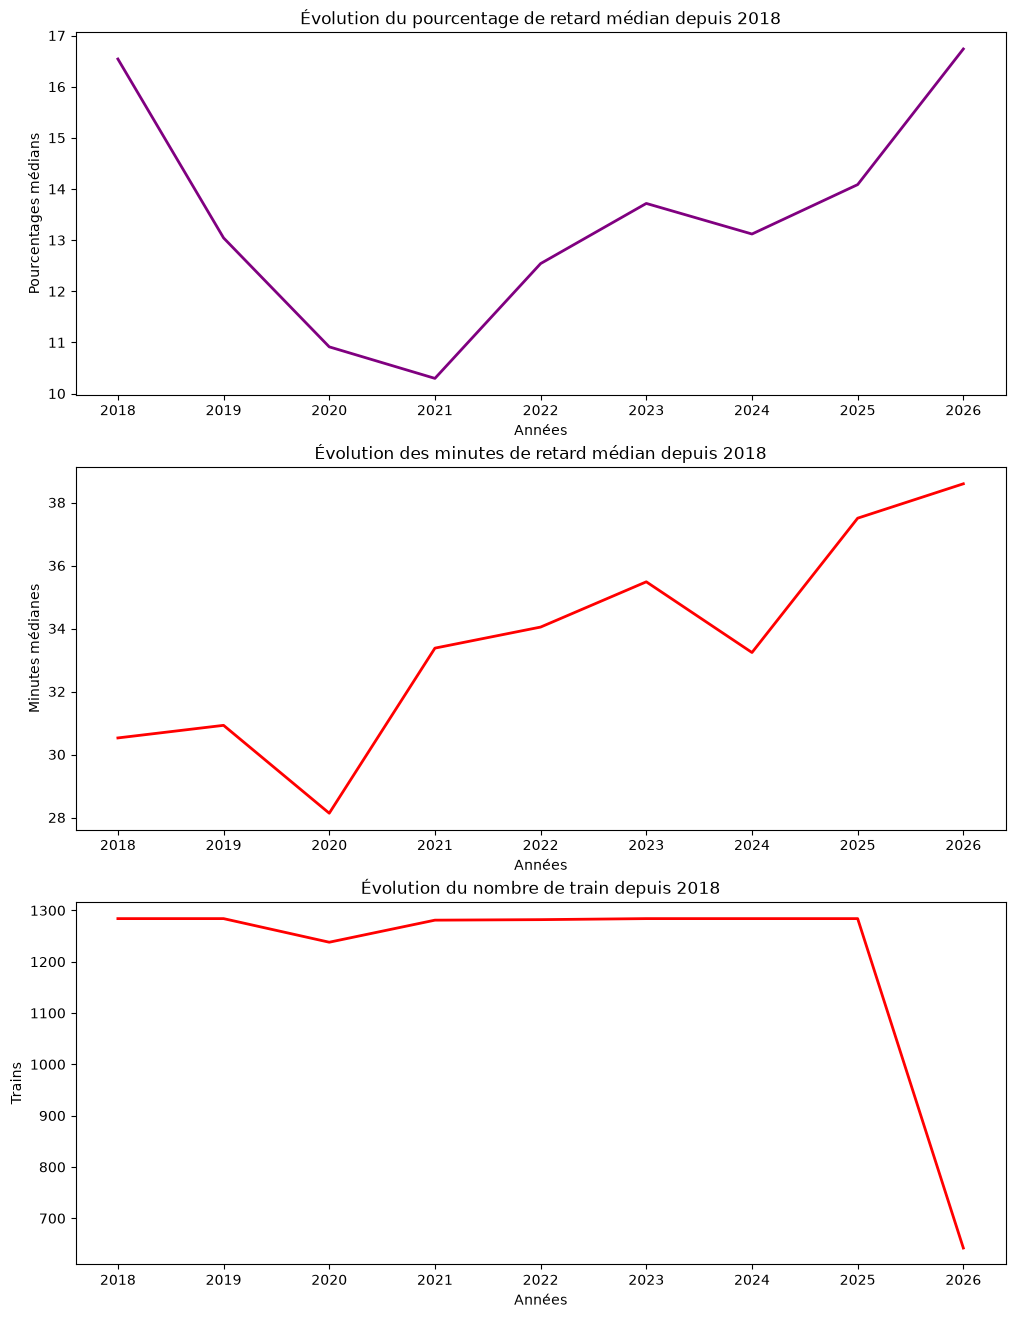

In [32]:
#Visualisation graphique de l'évolution du retard depuis 2018 : 

pourcentage_retard_mediane = df.groupby('année').pourcentage_retard.median() #calcul de la valeur médiane en %
min_retard_mediane = df.groupby('année').min_retard.median() #calcul de la valeur médiane en minutes
train_total_count = df.groupby('année').train_total.count()

#visualisation graphique : 

plt.figure(figsize=(12,16))
plt.subplot(3,1,1)
plt.plot(pourcentage_retard_mediane, c="purple", lw=2)
plt.title("Évolution du pourcentage de retard médian depuis 2018")
plt.xlabel("Années")
plt.ylabel("Pourcentages médians")
plt.subplot(3,1,2)
plt.plot(min_retard_mediane, c="red", lw=2)
plt.title("Évolution des minutes de retard médian depuis 2018")
plt.xlabel("Années")
plt.ylabel("Minutes médianes")
plt.subplot(3,1,3)
plt.plot(train_total_count, c="red", lw=2)
plt.title("Évolution du nombre de train depuis 2018")
plt.xlabel("Années")
plt.ylabel("Trains")

Cette représentation graphique illustre l'évolution des retards globaux de la SNCF depuis 2018. 
Nous pouvons formuler plusieurs observations en analysant ces courbes : 

* L'impact de l'épidémie de COVID-19 sur les retards (moins de passagers donc moins de congestion en gare et meilleure ponctualité)

* Depuis 2021, une augmentation drastique du nombre de retards sur les lignes.

Nous allons à présent chercher les lignes possèdant le plus de retard médian : 

**Nous commeçerons par la donnée pourcentage de retard par ligne**

In [34]:
#réalisation du classement des médianes pour l'année 2025 : 

df_2025 = df.loc[df["année"] == 2025]

classement_2025 = df_2025.groupby('ligne_TGV').pourcentage_retard.median().round(1).sort_values(ascending=False)

classement_2025.head(10)

ligne_TGV
CHAMBERY CHALLES LES EAUX - PARIS LYON    30.5
MACON LOCHE - PARIS LYON                  30.4
LYON PART DIEU - MARNE LA VALLEE          27.3
LYON PART DIEU - MARSEILLE ST CHARLES     24.4
LYON PART DIEU - LILLE                    24.2
MARNE LA VALLEE - LYON PART DIEU          23.9
ANNECY - PARIS LYON                       23.8
LYON PART DIEU - MONTPELLIER              23.1
ARRAS - PARIS NORD                        22.6
NICE VILLE - PARIS LYON                   21.7
Name: pourcentage_retard, dtype: float64

Text(0.5, 1.0, 'Classement des retard par lignes en pourcentage du total de trains en circulation')

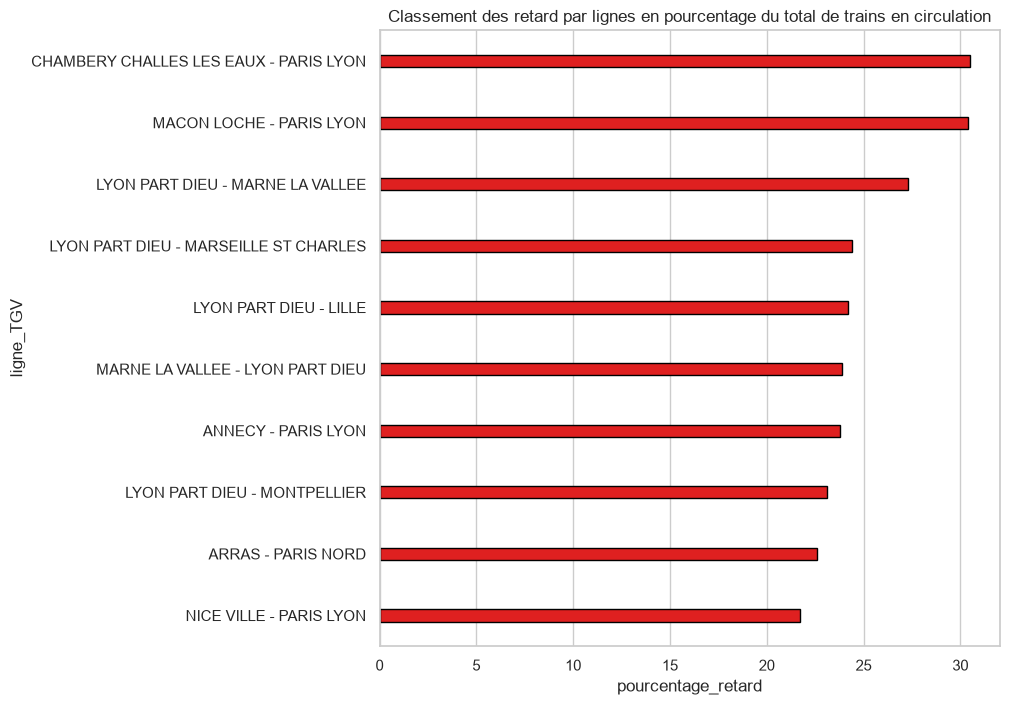

In [36]:
#visualisation graphique du classement : 

classement_2025 = pd.DataFrame(classement_2025)

plt.figure(figsize=(8,8))
sns.set_theme(style="whitegrid", palette="pastel")
sns.barplot(data= classement_2025.head(10), x="pourcentage_retard", y="ligne_TGV", orient="h", color="red", edgecolor="black", width=0.2, gap=0)
plt.title("Classement des retard par lignes en pourcentage du total de trains en circulation")

In [37]:
#réalisation du classement des médianes depuis 2018 : 

df_2018 = df.loc[df["année"] < 2026]

classement_2018 = df_2018.groupby("ligne_TGV").pourcentage_retard.median().sort_values(ascending=False)

classement_2018 = pd.DataFrame(classement_2018)

classement_2018.head(10)

,pourcentage_retard
ligne_TGV,
CHAMBERY CHALLES LES EAUX - PARIS LYON,25.312500
LYON PART DIEU - LILLE,25.000536
MACON LOCHE - PARIS LYON,23.807124
LYON PART DIEU - MARNE LA VALLEE,23.452769
ARRAS - PARIS NORD,21.273580
LYON PART DIEU - MARSEILLE ST CHARLES,21.239719
MARSEILLE ST CHARLES - LILLE,20.853081
DOUAI - PARIS NORD,20.550528
LYON PART DIEU - MONTPELLIER,20.212885


Text(0.5, 1.0, 'Classement des retard par lignes en pourcentage du total de trains en circulation depuis 2018')

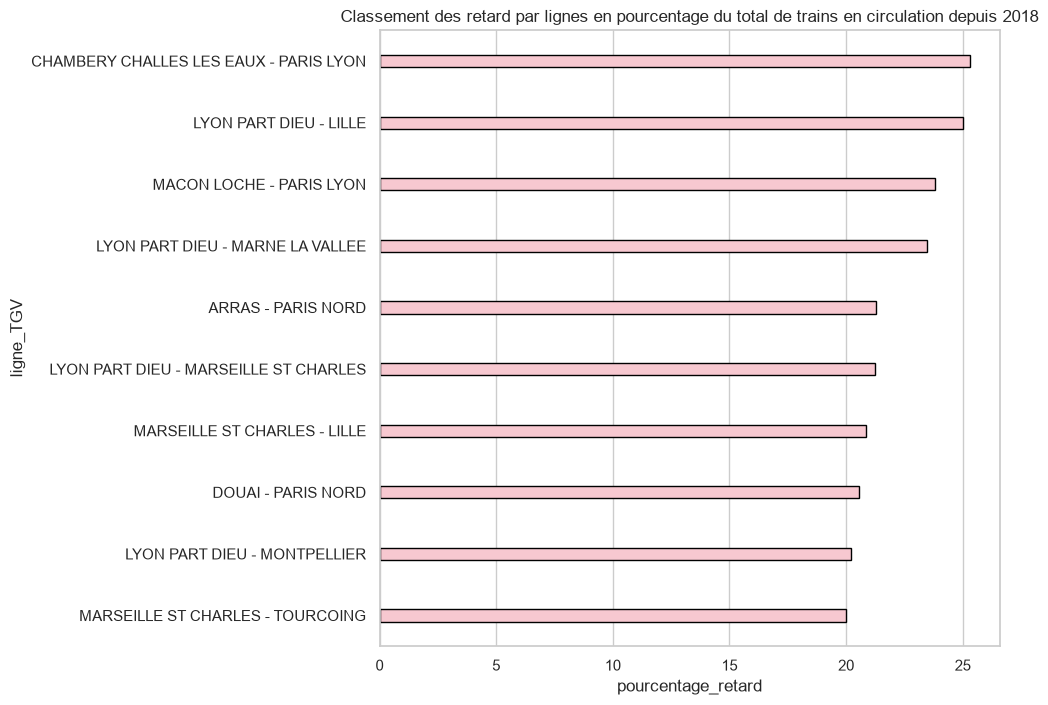

In [39]:
#visualisation graphique du résultat

plt.figure(figsize=(8,8))
plt_classement(classement_2018, 10, "pourcentage_retard", "ligne_TGV", "pink")
plt.title("Classement des retard par lignes en pourcentage du total de trains en circulation depuis 2018")

**A présent, nous allons analyser la donnée de retard par lignes en minutes**

In [41]:
#Calcul du classement pour la variable minutes pour l'année 2025 : 

classement_2025_minutes = sncf_classement(df_2025, 'min_retard', 10)

classement_2025_minutes

,min_retard
ligne_TGV,
MARSEILLE ST CHARLES - TOURCOING,59.2
PARIS LYON - MARSEILLE ST CHARLES,56.2
NICE VILLE - PARIS LYON,55.9
TOULON - PARIS LYON,55.5
PARIS LYON - PERPIGNAN,53.1
PARIS LYON - AIX EN PROVENCE TGV,53.0
MARSEILLE ST CHARLES - PARIS LYON,52.7
PARIS LYON - NICE VILLE,51.6
BORDEAUX ST JEAN - TOURCOING,51.3


Text(0.5, 1.0, 'Classement des retard par lignes en minutes médianes en 2025')

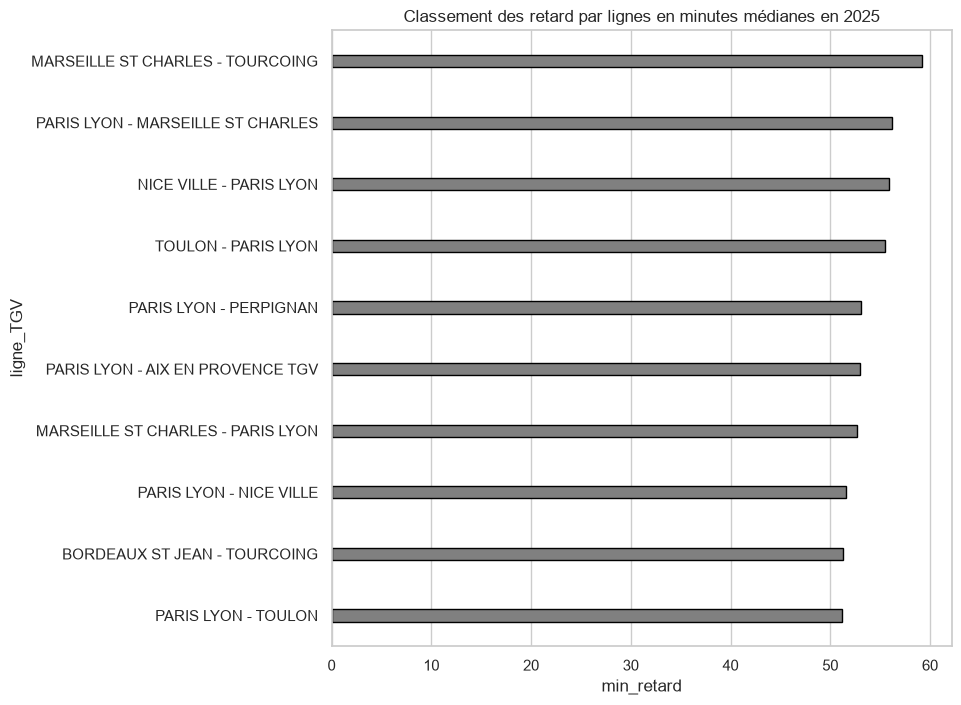

In [42]:
#visualisation graphique : 

plt.figure(figsize=(8,8))
plt_classement(classement_2025_minutes, 10, "min_retard", "ligne_TGV", "grey")
plt.title("Classement des retard par lignes en minutes médianes en 2025")

In [43]:
#Calcul du classement pour la variable minutes depuis 2018 : 

classement_2018_minutes = sncf_classement(df_2018, "min_retard", 10)

classement_2018_minutes = classement_2018_minutes.reset_index(names="ligne_TGV")

classement_2018_minutes

,ligne_TGV,min_retard
0,TOULOUSE MATABIAU - PARIS MONTPARNASSE,47.9
1,PARIS MONTPARNASSE - TOULOUSE MATABIAU,47.4
2,PARIS LYON - NICE VILLE,47.0
3,NICE VILLE - PARIS LYON,46.8
4,TOULON - PARIS LYON,46.7
5,AIX EN PROVENCE TGV - PARIS LYON,45.5
6,PERPIGNAN - PARIS LYON,45.2
7,RENNES - LYON PART DIEU,44.9
8,MARSEILLE ST CHARLES - PARIS LYON,44.7
9,PARIS LYON - PERPIGNAN,44.5


Text(0.5, 1.0, 'Classement des retard par lignes en minutes médianes depuis 2018')

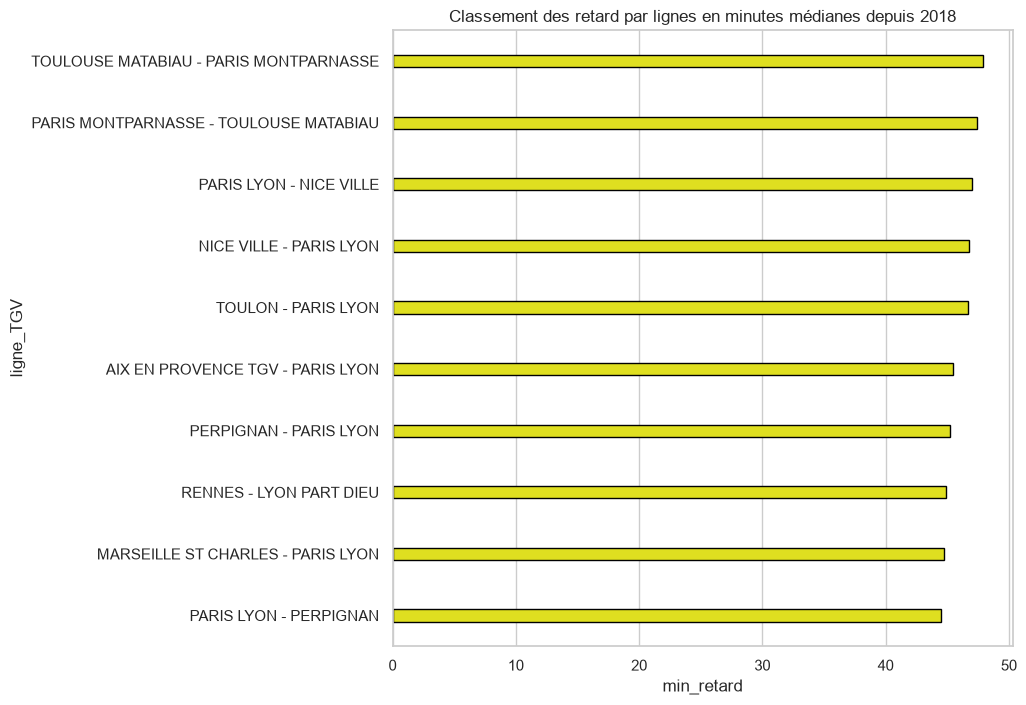

In [44]:
#visualisation graphique :

plt.figure(figsize=(8,8))
plt_classement(classement_2018_minutes, 10, "min_retard", "ligne_TGV", "yellow")
plt.title("Classement des retard par lignes en minutes médianes depuis 2018")

In [46]:
#Classement de l'augmentation du temps de trajet médian par ligne en pourcentage : 

classement_2025_percent = sncf_classement(df_2025, "pourcentage_retard_min", 10)
classement_2025_percent

,pourcentage_retard_min
ligne_TGV,
PARIS EST - REIMS,61.5
PARIS NORD - ARRAS,59.2
REIMS - PARIS EST,51.2
PARIS LYON - DIJON VILLE,47.0
LE MANS - PARIS MONTPARNASSE,45.9
ARRAS - PARIS NORD,44.5
PARIS NORD - LILLE,42.8
DIJON VILLE - PARIS LYON,41.8
PARIS MONTPARNASSE - LE MANS,40.1


Text(0.5, 1.0, 'Classement du temps perdu médianes en pourcentage en 2025')

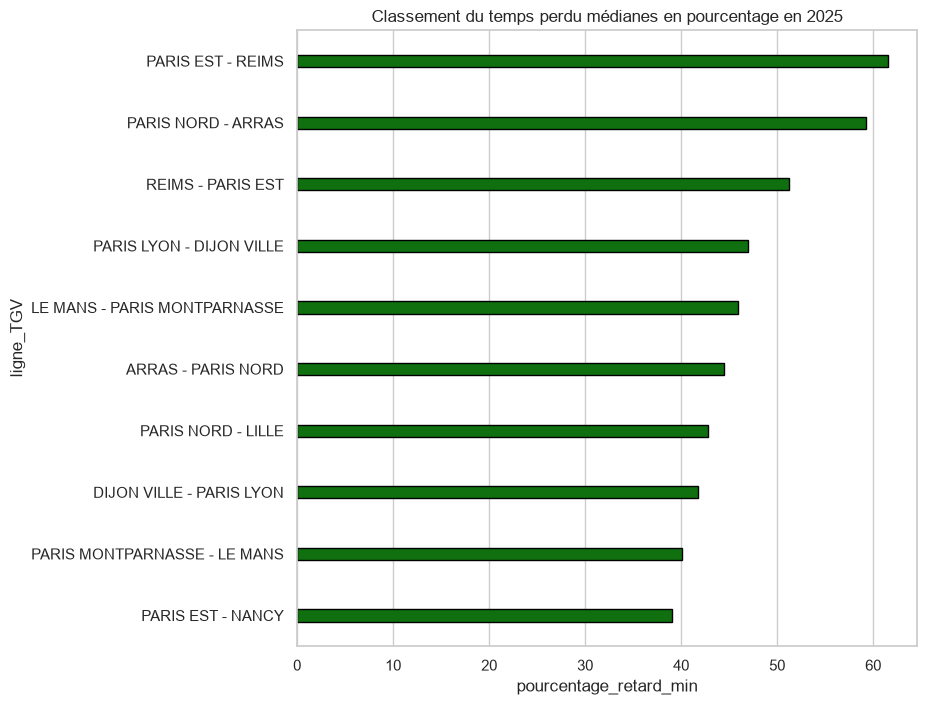

In [47]:
#visualisation graphique : 

plt.figure(figsize=(8,8))
plt_classement(classement_2025_percent, 10, "pourcentage_retard_min", "ligne_TGV", "green")
plt.title("Classement du temps perdu médianes en pourcentage en 2025")

In [48]:
#Classement de l'augmentation du temps de trajet médian par ligne en pourcentage depuis 2018 : 

classement_2018_percent = sncf_classement(df_2018, "pourcentage_retard_min", 10)
classement_2018_percent

,pourcentage_retard_min
ligne_TGV,
PARIS EST - REIMS,47.6
PARIS NORD - ARRAS,44.7
REIMS - PARIS EST,41.9
LE MANS - PARIS MONTPARNASSE,38.0
DIJON VILLE - PARIS LYON,37.6
ARRAS - PARIS NORD,37.0
PARIS MONTPARNASSE - LE MANS,36.1
PARIS LYON - DIJON VILLE,34.5
PARIS NORD - LILLE,33.4


Text(0.5, 1.0, 'Classement du temps perdu médianes en pourcentage depuis 2018')

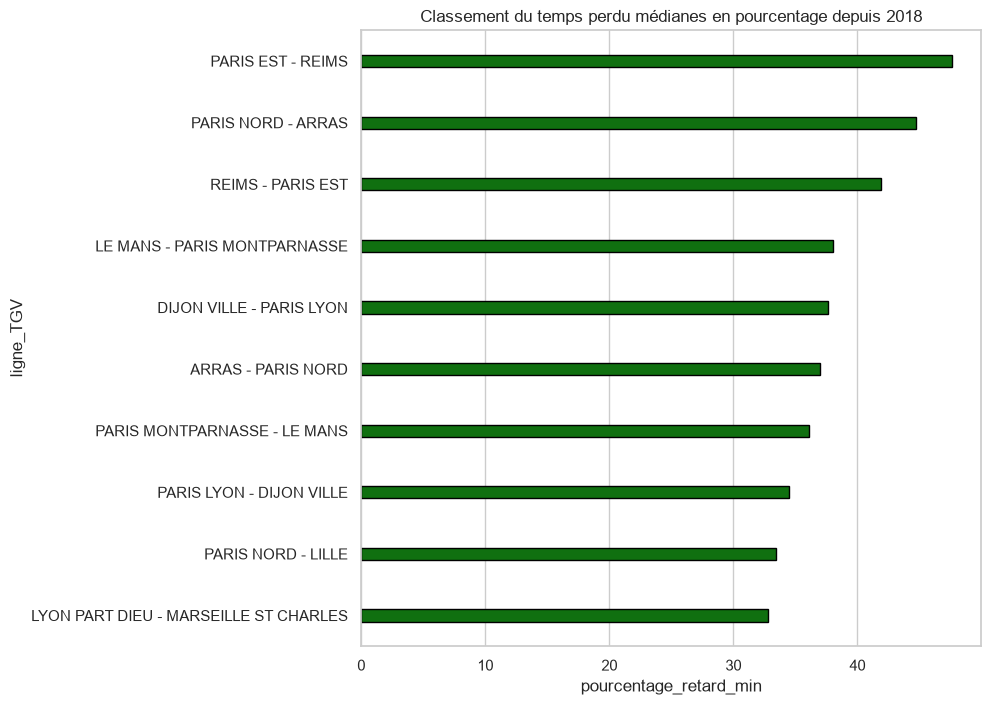

In [49]:
#visualisation graphique : 

plt.figure(figsize=(8,8))
plt_classement(classement_2018_percent, 10, "pourcentage_retard_min", "ligne_TGV", "green")
plt.title("Classement du temps perdu médianes en pourcentage depuis 2018")

In [50]:
#Stockage des fichiers en csv pour transfert sur Google Sheet : 

export = {"classement_2018" : classement_2018, 
          "classement_2025" : classement_2025, 
          "classement_2025_minutes" : classement_2025_minutes, 
          "classement_2018_minutes" : classement_2018_minutes, 
          "classement_2018_percent" : classement_2018_percent, 
          "classement_2025_percent" : classement_2025_percent }#nom des df à exporter

for nom_frame, frame in export.items() : 
    frame.to_csv(f"output/{nom_frame}.csv", index=False)
    print(f"{nom_frame} exporté en .csv avec succès")


classement_2018 exporté en .csv avec succès
classement_2025 exporté en .csv avec succès
classement_2025_minutes exporté en .csv avec succès
classement_2018_minutes exporté en .csv avec succès
classement_2018_percent exporté en .csv avec succès
classement_2025_percent exporté en .csv avec succès


Nous allons à présent pouvoir réaliser le test d'analyse de variance sur nos données, afin d'identifier si les retards entre lignes sont statistiquement différents.

Nous ferons usage du test non paramétrique de Kruskal Wallis, étant donné que nos données ne suivent pas une loi normale (identifiée en phase 2)

In [51]:
from scipy import stats
import scikit_posthocs as sp

def k_w(df : pd.DataFrame, vl : str, alpha : int) -> float : 
    kstat, pval = stats.kruskal(*[group[vl].values for name, group in df.groupby('ligne_TGV')]) #calcul du Pvalue
    if pval <= alpha  :
        dunn = sp.posthoc_dunn(
            df, 
            val_col = vl,
            group_col = "ligne_TGV",
            p_adjust="bonferroni" #correction multiplication de tests
        )

        significatif = dunn < alpha
        nb_diff = significatif.sum(axis=1) - 1
        resultat = nb_diff.sort_values(ascending=False)
        return resultat
    else : 
        print(f"Le test statistique n'est pas significatif {pval} est supérieur à {alpha} pour la variable {vl}")

    

In [52]:
kruskal_w = k_w(df_2018, "pourcentage_retard", 0.05) #calcul du kuskal + posthoc sur la variable % retard (indépendante)

kruskal_w = pd.DataFrame(kruskal_w)

kruskal_w = kruskal_w.reset_index(names="ligne_TGV") #création de l'index 

kruskal_w = kruskal_w.rename(columns={0 : "résultat_kw"}) #changement du nom de la colonne pour plus de lisibilité

kruskal_w.head(10)

,ligne_TGV,résultat_kw
0,CHAMBERY CHALLES LES EAUX - PARIS LYON,90
1,LYON PART DIEU - LILLE,88
2,LYON PART DIEU - MARNE LA VALLEE,84
3,MACON LOCHE - PARIS LYON,83
4,ARRAS - PARIS NORD,82
5,DOUAI - PARIS NORD,80
6,PARIS EST - NANCY,80
7,PARIS LYON - LYON PART DIEU,77
8,LYON PART DIEU - MARSEILLE ST CHARLES,73
9,BESANCON FRANCHE COMTE TGV - PARIS LYON,71


In [53]:
#Visualisation en pourcentage total des lignes des kw : 

kruskal_w['percent'] = (kruskal_w["résultat_kw"] * 100)/116

kruskal_w.head(10)

,ligne_TGV,résultat_kw,percent
0,CHAMBERY CHALLES LES EAUX - PARIS LYON,90,77.586207
1,LYON PART DIEU - LILLE,88,75.862069
2,LYON PART DIEU - MARNE LA VALLEE,84,72.413793
3,MACON LOCHE - PARIS LYON,83,71.551724
4,ARRAS - PARIS NORD,82,70.689655
5,DOUAI - PARIS NORD,80,68.965517
6,PARIS EST - NANCY,80,68.965517
7,PARIS LYON - LYON PART DIEU,77,66.379310
8,LYON PART DIEU - MARSEILLE ST CHARLES,73,62.931034
9,BESANCON FRANCHE COMTE TGV - PARIS LYON,71,61.206897


In [54]:
#fusion avec les % depuis 2018 pour croiser la donnée : 

kw_classement = pd.merge(classement_2018, kruskal_w, on="ligne_TGV", how = "left")

kw_classement.head(10)

,ligne_TGV,pourcentage_retard,résultat_kw,percent
0,CHAMBERY CHALLES LES EAUX - PARIS LYON,25.312500,90,77.586207
1,LYON PART DIEU - LILLE,25.000536,88,75.862069
2,MACON LOCHE - PARIS LYON,23.807124,83,71.551724
3,LYON PART DIEU - MARNE LA VALLEE,23.452769,84,72.413793
4,ARRAS - PARIS NORD,21.273580,82,70.689655
5,LYON PART DIEU - MARSEILLE ST CHARLES,21.239719,73,62.931034
6,MARSEILLE ST CHARLES - LILLE,20.853081,70,60.344828
7,DOUAI - PARIS NORD,20.550528,80,68.965517
8,LYON PART DIEU - MONTPELLIER,20.212885,64,55.172414
9,MARSEILLE ST CHARLES - TOURCOING,20.000000,56,48.275862


In [63]:
kruskal_w_min = k_w(df_2018, "min_retard", 0.05) #calcul du kuskal + posthoc sur la variable min retard (indépendante)

kruskal_w_min = pd.DataFrame(kruskal_w_min)

kruskal_w_min = kruskal_w_min.rename(columns={0 : "résultat_kw"}) #changement du nom de la colonne pour plus de lisibilité

kruskal_w_min = kruskal_w_min.reset_index(names="ligne_TGV") #création de l'index 

kruskal_w_min.head(10)

,ligne_TGV,résultat_kw
0,ARRAS - PARIS NORD,85
1,DOUAI - PARIS NORD,85
2,TOURS - PARIS MONTPARNASSE,85
3,ST PIERRE DES CORPS - PARIS MONTPARNASSE,84
4,REIMS - PARIS EST,81
5,PARIS MONTPARNASSE - TOURS,81
6,LILLE - PARIS NORD,81
7,PARIS MONTPARNASSE - ST PIERRE DES CORPS,79
8,LE CREUSOT MONTCEAU MONTCHANIN - PARIS LYON,78
9,PARIS LYON - NICE VILLE,77


In [56]:
#Visualisation en pourcentage total des lignes des kw : 

kruskal_w_min['percent'] = (kruskal_w_min["résultat_kw"] * 100)/116

kruskal_w_min.head(10)

,ligne_TGV,résultat_kw,percent
0,DOUAI - PARIS NORD,86,74.137931
1,TOURS - PARIS MONTPARNASSE,86,74.137931
2,ARRAS - PARIS NORD,85,73.275862
3,ST PIERRE DES CORPS - PARIS MONTPARNASSE,84,72.413793
4,LILLE - PARIS NORD,84,72.413793
5,PARIS MONTPARNASSE - TOURS,80,68.965517
6,REIMS - PARIS EST,80,68.965517
7,PARIS MONTPARNASSE - ST PIERRE DES CORPS,78,67.241379
8,LE CREUSOT MONTCEAU MONTCHANIN - PARIS LYON,77,66.379310
9,NICE VILLE - PARIS LYON,77,66.379310


In [57]:
kw_classement_min = pd.merge(classement_2018_minutes, kruskal_w_min, on="ligne_TGV", how="left")

kw_classement_min.head(10)

,ligne_TGV,min_retard,résultat_kw,percent
0,TOULOUSE MATABIAU - PARIS MONTPARNASSE,47.9,76,65.517241
1,PARIS MONTPARNASSE - TOULOUSE MATABIAU,47.4,77,66.379310
2,PARIS LYON - NICE VILLE,47.0,77,66.379310
3,NICE VILLE - PARIS LYON,46.8,77,66.379310
4,TOULON - PARIS LYON,46.7,77,66.379310
5,AIX EN PROVENCE TGV - PARIS LYON,45.5,68,58.620690
6,PERPIGNAN - PARIS LYON,45.2,72,62.068966
7,RENNES - LYON PART DIEU,44.9,60,51.724138
8,MARSEILLE ST CHARLES - PARIS LYON,44.7,71,61.206897
9,PARIS LYON - PERPIGNAN,44.5,77,66.379310


In [58]:
#export au .csv pour le dashboard : 

kw_classement_min.to_csv(f"output/kw_classement_min.csv", index=False)

**CONCLUSIONS :**

Notre analyse s'achève par l'identification des 7 lignes dont les retards doivent être audités afin de comprendre leurs différences avec les autres :

In [59]:
#tableau final : 

kw_classement.head(7)

,ligne_TGV,pourcentage_retard,résultat_kw,percent
0,CHAMBERY CHALLES LES EAUX - PARIS LYON,25.312500,90,77.586207
1,LYON PART DIEU - LILLE,25.000536,88,75.862069
2,MACON LOCHE - PARIS LYON,23.807124,83,71.551724
3,LYON PART DIEU - MARNE LA VALLEE,23.452769,84,72.413793
4,ARRAS - PARIS NORD,21.273580,82,70.689655
5,LYON PART DIEU - MARSEILLE ST CHARLES,21.239719,73,62.931034
6,MARSEILLE ST CHARLES - LILLE,20.853081,70,60.344828


Mais également par les classements et graphiques établis plus haut dans ce notebook

***PISTE FUTURES***

La suite porterait sur plusieurs problématiques. Premièrement, il serait pertinent de s'intéresser au lien entre l'augmentation du nombre de voyageurs par ligne et la variation des retards sur ces mêmes lignes, afin de comprendre les causes réelles de l'augmentation du pourcentage médian de retard par ligne. 
Ensuite, il serait pertinent de comprendre en profondeur les causes des retards des lignes exposées dans notre analyse, afin de pouvoir mettre en place des correctifs précis, favorisant la satisfaction des voyageurs.

***LIMITES***

Notre analyse possède un ensemble de limites qu'il est important de mentionner. Premièrement, l'origine de des données peut être sujette à des biais. En effet, le retard étant une donnée assez importante et potentiellement sensible chez la SNCF, la publication de données exposant des retards importants pourrait dénigrer l'entreprise, c'est pour cela qu'il faut rester prudent quant aux conclusions exposées plus haut. Ensuite, la présence de nombreux outliers perturbe l'analyse, notamment dans les choix des tests (non paramétriques), pouvant réduire la puissance de notre recherche. Enfin, l'absence de données précises concernant les passagers par lignes, ou des commentaires de retard mieux informés, réduise nos possibilités d'analyse.